<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# __K Means Clustering with Python__



## **Introduction**
K-Means is an unsupervised learning algorithm that partitions data into \(K\) compact clusters. The diagram below summarizes the main workflow: initialize cluster centers, assign observations, update the centers, and repeat until the solution stabilizes.
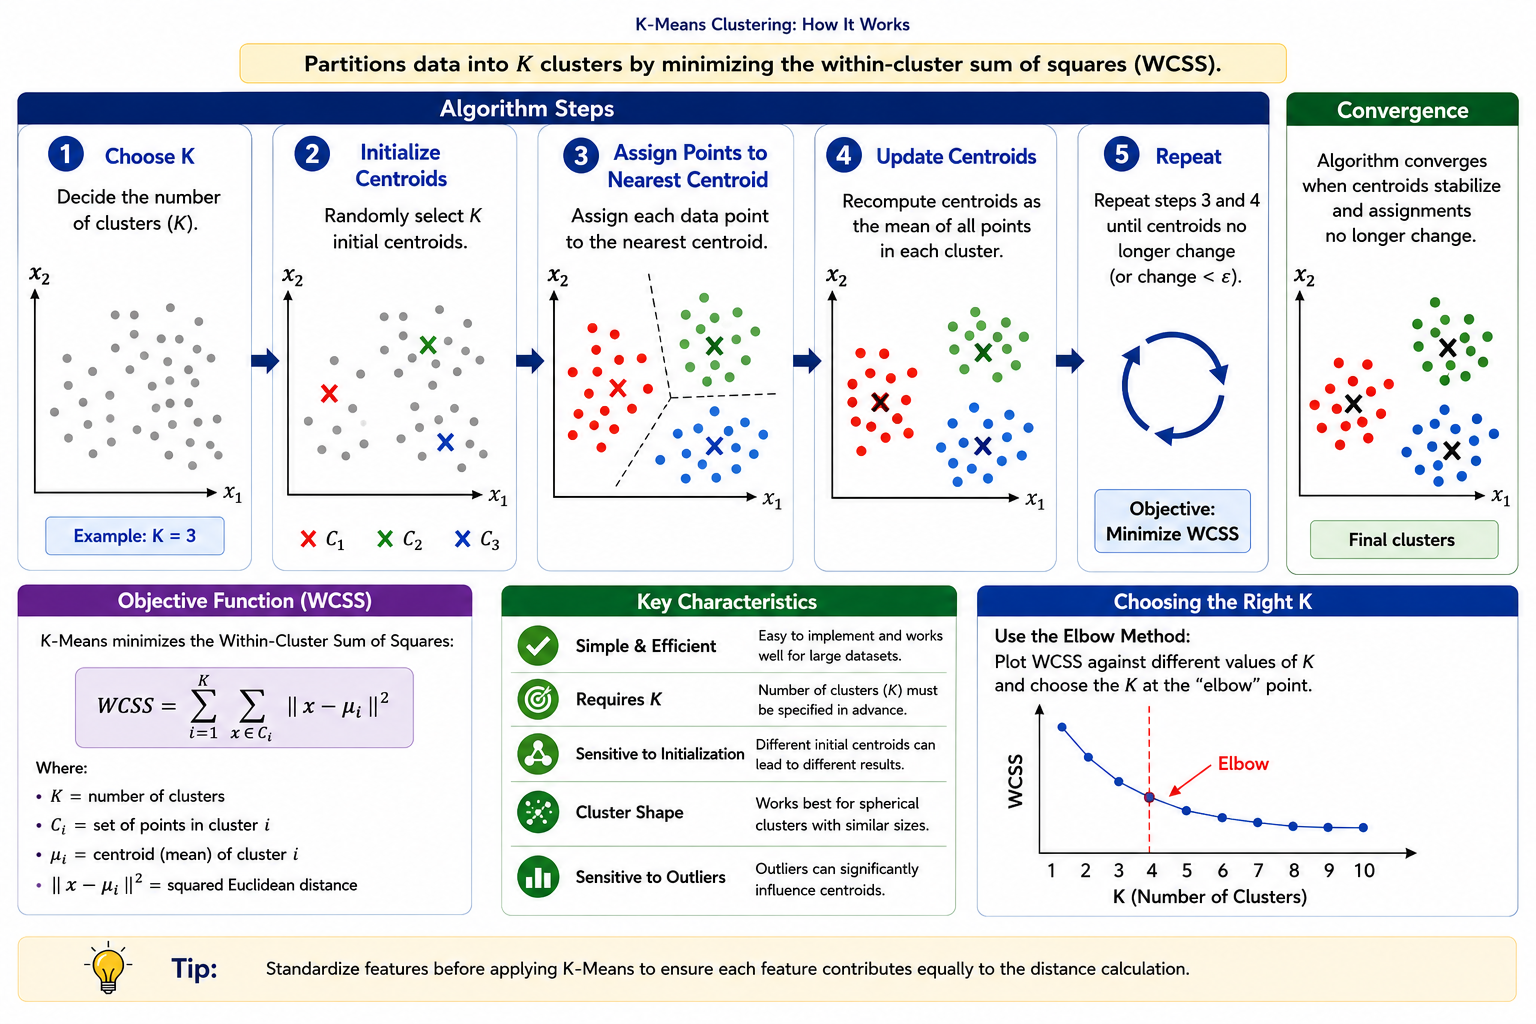
Each cluster is represented by a **centroid**, the average position of the observations assigned to that cluster:

$$
\mu_k = \frac{1}{N_k} \sum_{i=1}^{N_k} x_i
$$

where $\mu_k$ is the centroid of cluster $k$, $N_k$ is the number of observations in that cluster, and $x_i$ represents an individual observation.

K-Means commonly uses Euclidean distance to measure similarity between observations and centroids:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
$$

The optimization objective is to minimize the within-cluster sum of squares (WCSS), also called **inertia**:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

where $C_k$ is cluster $k$, $x_i$ is an observation assigned to that cluster, and $\mu_k$ is the corresponding centroid.

**Inertia measures cluster compactness**. Lower inertia means observations are closer to their assigned centroids. Because inertia usually decreases as $K$ increases, it should not be used by itself to choose the best number of clusters.

Another useful metric is the **silhouette coefficient**, which compares how well an observation fits within its own cluster relative to the nearest other cluster:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where $a(i)$ is the average distance from observation $i$ to other observations in the same cluster, and $b(i)$ is the average distance from observation $i$ to observations in the nearest different cluster.

The silhouette coefficient ranges from -1 to 1:

- values close to 1 indicate well-separated clusters
- values near 0 indicate observations near a cluster boundary
- values close to -1 indicate observations that may be assigned to the wrong cluster

Because K-Means depends on distance calculations, feature scaling is important before clustering. Standardization is commonly used so that features with larger numeric ranges do not dominate the distance calculation:

$$
z = \frac{x - \mu}{\sigma}
$$

The number of clusters is often selected using the **Elbow Method**, which looks for the point where adding more clusters produces only a small additional reduction in inertia.


### **About K Means**

| Pros | Cons |
|---|---|
| Easy to implement | Must manually choose $K$ |
| Scales well to large datasets | Sensitive to outliers |
| Fast and computationally efficient | May converge to a local minimum |
| Works well for compact clusters | May not perform well on clusters with varying density or irregular shapes |



### **Summary**

K-Means clustering groups similar data points by iteratively updating cluster centroids to minimize within-cluster distance. Due to its simplicity and efficiency, it is widely used in customer segmentation, recommendation systems, and pattern analysis.


### **Project Scenario**
**Customer Segmentation for Personalized Marketing**

Retailers often need to understand how customers differ in their purchasing behavior so they can design more effective marketing strategies. Instead of treating all customers the same, a company can use customer attributes such as age, income, and spending score to identify groups with similar characteristics.

K-Means clustering is an unsupervised learning algorithm that can discover these customer segments by grouping observations around representative centroids. In this lab, you will use K-Means to identify meaningful customer groups and interpret how those clusters can support personalized marketing, product recommendations, and business decision-making.

### **Workflow**
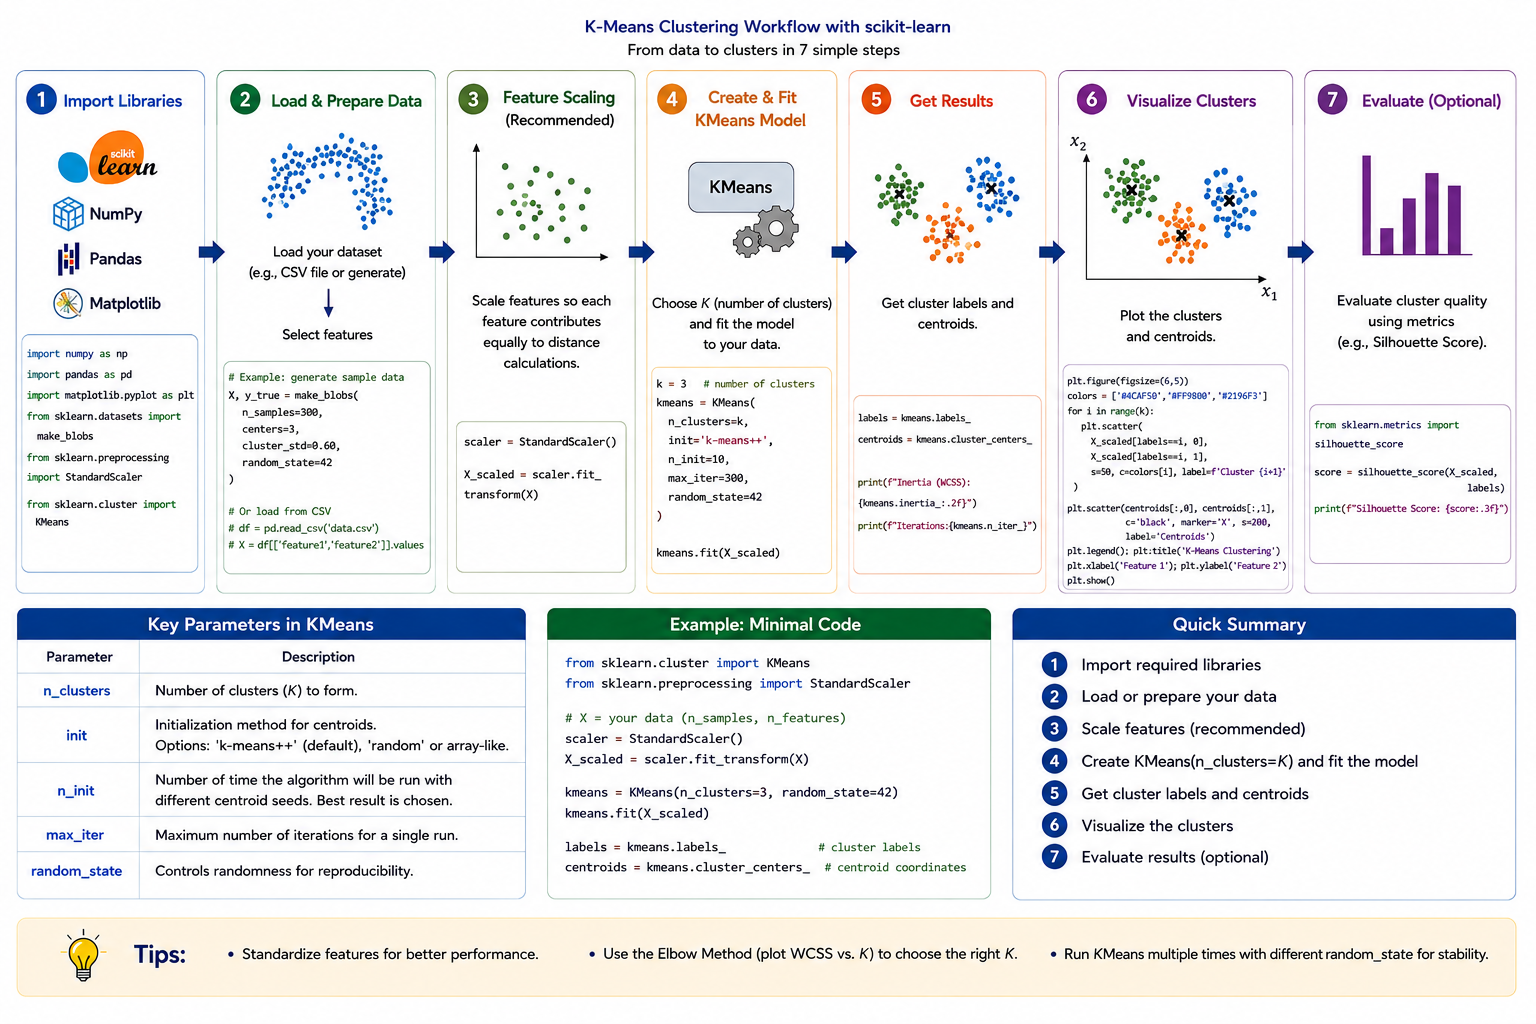

## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
3. [Example 1: Visual intuition](<#Example-1:-Visual-intuition>)
4. [Example 2: Segmenting Customer Data](<#Example-2:-Segmenting-Customer-Data>)
    1. [Problem Statement](<#Problem-Statement>)
    2. [About the dataset](<#About-the-dataset>)
    3. [Loading the dataset](<#Loading-the-dataset>)
    4. [Getting familiar with the data](<#Getting-familiar-with-the-data>)
    5. [Clustering the data using K Means](<#Clustering-the-data-using-K-Means>)
5. [Example 3: Image Segmentation](<#Example-3:-Image-Segmentation>)
    1. [Loading the data](<#Loading-the-data>)
    2. [Segmenting the image using 2 clusters](<#Segmenting-the-image-using-2-clusters>)
    3. [Converting to black and white](<#Converting-to-black-and-white>)
6. [Exercises](<#Exercises>)
    1. [Exercise 1 - Fitting KMeans With k=2](<#Exercise-1---Fitting-KMeans-With-k=2>)
    2. [Exercise 2 - Viewing Segmented Image](<#Exercise-2---Viewing-Segmented-Image>)
    3. [Exercise 3 - Fitting KMeans With k=4 and Viewing Segmented Image](<#Exercise-3---Fitting-KMeans-With-k=4-and-Viewing-Segmented-Image>)


## **Objectives**

In this notebook, we will learn the fundamentals of K-Means clustering and apply it to customer segmentation and image clustering.

By the end of this lab, you will be able to:
 - Explain the theory behind K Means Clustering
 - Implement K Means Clustering to perform exploratory data analysis
 - Perform Image segmentation using K Means


----


## **Setup**

For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the corresponding code cell below.


In [163]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

### **Importing Required Libraries**


In [164]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt
%matplotlib inline

## **Example 1: Visual intuition**
Take a look at the following animation for some physical intuition of what's going on during each iteration.

It shows several iterations of K Means Clustering (steps 3 & 4 in previous section) applied to a sample dataset with <code>k = 2</code> clusters.

![img](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/KMeansClustering_example.gif)

In each iteration, you can see the previous locations of the centroids (faded) and their current location after they were moved to the mean of the data points assigned to that cluster. The data points are colored by the cluster they are assigned to after that iteration.

Finally, on iteration 6, we see the centroids of the clusters remain unchanged - this means the KMeans algorithm has converged and finished.


## **Example 2: Segmenting Customer Data**

K-Means is commonly used for customer segmentation. By grouping customers with similar purchasing behavior, businesses can better understand customer preferences and create more targeted marketing strategies.

In this example, we will use K-Means clustering to group mall customers based on their demographic and spending behavior.


### **Problem Statement**

Suppose you are a data scientist at MegaMind Sporting Goods Ltd.

Your task is to segment customers into groups based on their purchasing habits. Once customers are grouped into clusters, the marketing team can design personalized promotions and recommendations for each customer group.


### **About the dataset**

We will explore a simple example of customer segmentation using the [Mall Customers](https://github.com/SteffiPeTaffy/machineLearningAZ/blob/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv) dataset. It contains customer demographic and spending information collected from a shopping mall..

* **CustomerID** - A unique identifying number for each customer
* **Gender**
* **Age**
* **Annual Income** - The annual income of the customer given in thousands of dollars
* **Spending Score** - The spending score is assigned by the mall based on customer purchasing behavior and shopping habits.

The goal is to identify groups of customers with similar characteristics using K-Means clustering.

### **Loading the dataset**


In [165]:
# Download the dataset and read it into a Pandas dataframe
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/CustomerData.csv",
    index_col=0,
)

Let's take a peek at our dataset to ensure it was loaded properly.


In [166]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


### **Getting familiar with the data**

First, let's take a look at the data we have to gain a better general understanding of it before we attempt any clustering.

Let's start by looking at the distributions of some of the features.


We can start by analyzing the ratio of male to female customers that were surveyed.


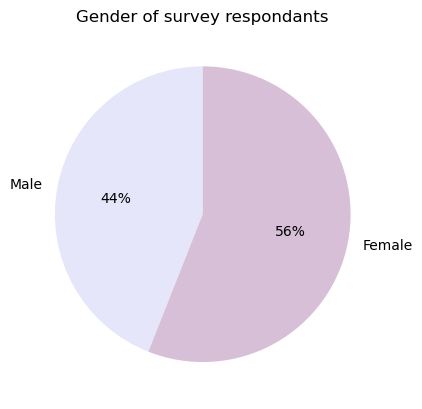

In [167]:
num_male = df[df["Gender"] == "Male"].shape[0]
num_female = df[df["Gender"] == "Female"].shape[0]
plt.pie(
    [num_male, num_female],
    labels=["Male", "Female"],
    startangle=90,
    autopct="%1.f%%",
    colors=["lavender", "thistle"],
)
plt.title("Gender of survey respondants")
plt.show()

We see that we have slightly more female respondents in our survey. Next, let's plot histograms of the age and annual incomes of the customers.


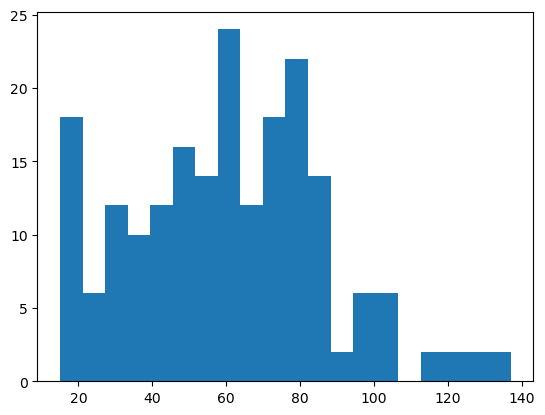

In [168]:
plt.hist(df["Annual Income (k$)"], bins=20)
plt.show()

Our distribution appears slightly skewed to the right. Not as many people are making over $100k per year.

Let's take a look at people's annual income vs. spending score:


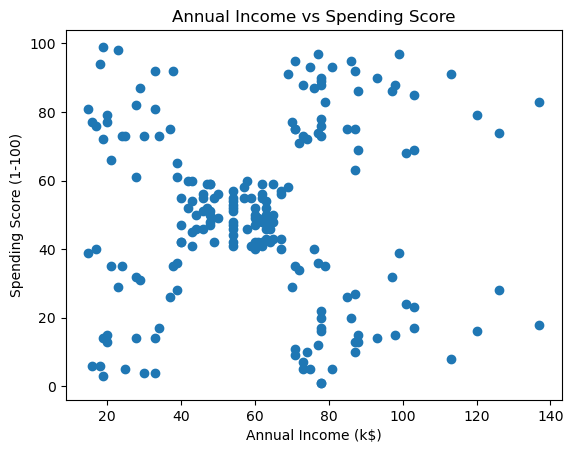

In [169]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()

This looks promising, we can see our customers seem to fall into ~5 categories:
 1. __Low__ income, __high__ spending.
 2. __High__ income, __low__ spending.
 3. __Low__ income, __low__ spending.
 4. __High__ income, __low__ spending.
 5. __Medium__ income, __medium__ spending.

If we manage to segment our existing customers into these 5 categories, we will obtain exactly the information John requires:


### **Clustering the data using K Means**

Let's start clustering our data!

To do so, we simply load the <code>sklearn.cluster.KMeans</code> object - with our desired number of clusters <code>k = 5</code>:


In [170]:
km = KMeans(n_clusters=5, random_state=42)
km.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


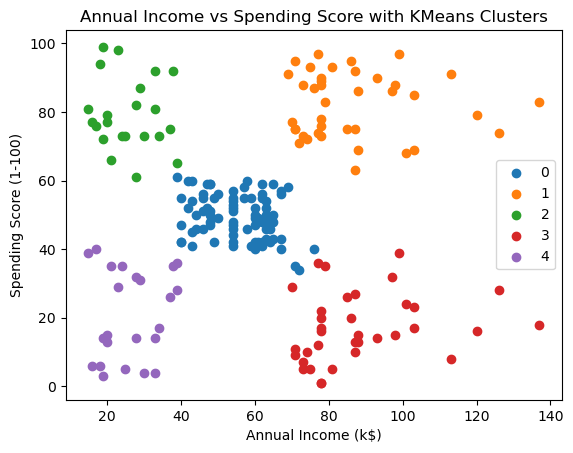

'We can see that our clusters are not perfect, but we have managed to group our customers in 5 categories.'

In [171]:
for label in np.unique(km.labels_):
    X_ = X[label == km.labels_]
    plt.scatter(
        X_["Annual Income (k$)"], X_["Spending Score (1-100)"], label=label
    )
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score with KMeans Clusters")
plt.legend()
plt.show()

"""We can see that our clusters are not perfect, but we have managed to group our customers in 5 categories."""

Awesome! Our KMeans algorithm was able to correctly group our data into the 5 categories that we initially noticed


## **Example 3: Image Segmentation**

Image segmentation divides an image into meaningful regions or objects by detecting their boundaries. It helps computers identify and analyze different parts of an image more accurately. Clustering methods, such as K-means, can be used for image segmentation by grouping pixels based on features like brightness or color values.

CNN-based methods usually perform better for image segmentation because they can learn complex features and object shapes. However, K-means is still widely used because it is simple, fast, and does not require labeled training data.

Various clustering can be used for this task.

__How__ is this done?:
 1. We cluster pixels using their brightness (grayscale) or RGB values (color).
 2. We replace each pixel with the average brightness or RGB value of pixels in their cluster.

Let's look at an example using KMeans:


### **Loading the data**

Let's start by loading the data into a <code>numpy.array</code> and taking a look at the image:


The image is 490px by 487px


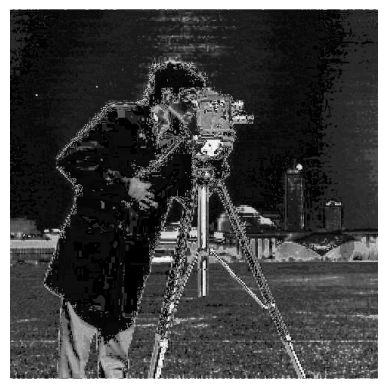

In [172]:
from PIL import Image
import urllib.request

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/cameraman.png"

img = np.array(Image.open(urllib.request.urlopen(url)))

print(f"The image is {img.shape[0]}px by {img.shape[1]}px")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

### **Segmenting the image using 2 clusters**

In this example, we will segment our image into <code>k = 2</code> color-clusters:


In [173]:
k = 2

X = img.reshape(-1, 1)
km = KMeans(n_clusters=k, random_state=42)

In [174]:
km.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'



Let's see our segmented image; once we replace each pixel with the mean of the cluster it belongs to:


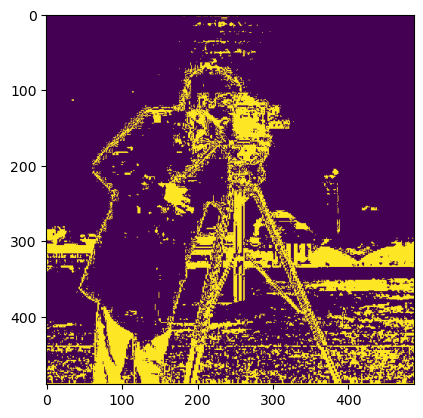

In [175]:
seg = np.zeros(X.shape)
for i in range(k):
    seg[km.labels_ == i] = km.cluster_centers_[i]
seg = seg.reshape(img.shape)
plt.imshow(seg)

Awesome! Even as humans, we can still easily recognize our image after segmentation with <code>k = 2</code> colors.

### **Converting to black and white**

Alternatively, we may view the image in black and white:


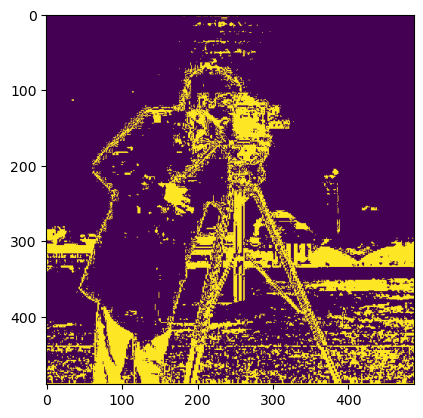

In [176]:
## creates an empty segmentation array where each pixel is initially assigned value 0.
seg = np.zeros(X.shape)

threshold = np.mean(km.cluster_centers_)

for i in range(k):
    seg[km.labels_ == i] = 255 if km.cluster_centers_[i] > threshold else 0

seg = seg.reshape(img.shape).astype(np.uint8)
plt.imshow(seg)

## **Exercises**

In this section, we will segment another image; this time in full-color with various values for k.

Please run the following cell to load the data for the exercises:


(426, 640, 3)


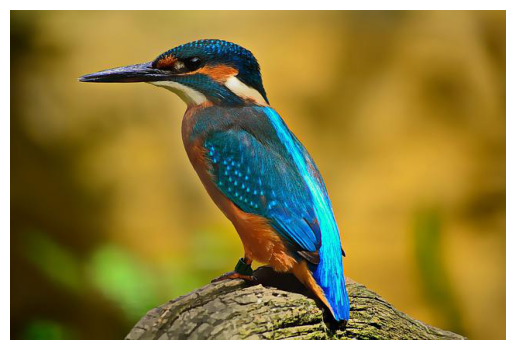

In [177]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/images/kingfisher.jpeg"

img = np.array(Image.open(urllib.request.urlopen(url)))
print(img.shape)
plt.imshow(img)
plt.axis("off")
plt.show()

### **Exercise 1 - Fitting KMeans With k=2**


In [178]:
# Enter your solution here
## image is RGB, so we changed the image into a long list of pixels:
X = img.reshape(-1, 3)
X.shape

(272640, 3)

In [179]:
k = 2

km = KMeans(n_clusters=k, random_state=42)
km.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### **Exercise 2 - Viewing Segmented Image**


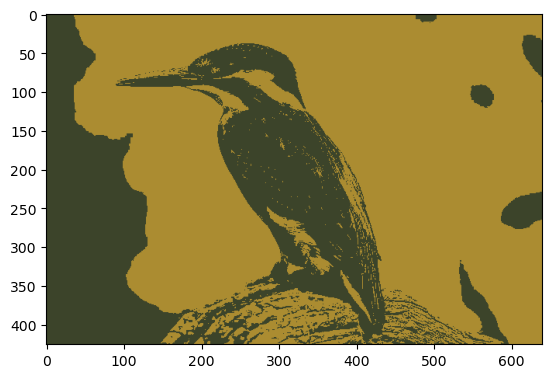

In [180]:
# Enter your solution here
seg = np.zeros(X.shape)
for i in range(k):
    seg[km.labels_ == i] = km.cluster_centers_[i]
seg = seg.reshape(img.shape).astype(np.uint8)
plt.imshow(seg)

### **Exercise 3 - Fitting KMeans With k=4 and Viewing Segmented Image**


In [181]:
# Enter your solution here

k = 4

km = KMeans(n_clusters=k, random_state=42)
km.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


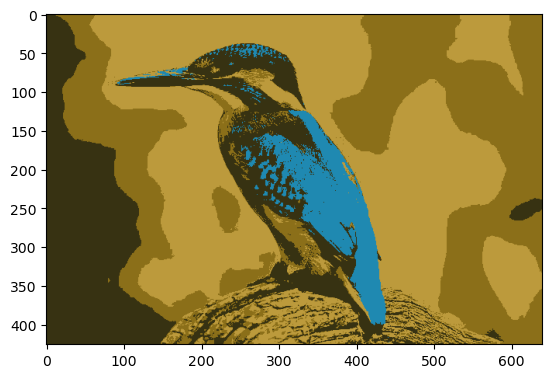

In [182]:
# Enter your solution here
seg = np.zeros(X.shape)
for i in range(k):
    seg[km.labels_ == i] = km.cluster_centers_[i]
seg = seg.reshape(img.shape).astype(np.uint8)
plt.imshow(seg)

In [ ]:
# Initialize an empty list to store the sum of squared distances for each model
results = []

for k in range(2, 10):  # silhouette needs k >= 2
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)

    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
        }
    )


metrics_df = pd.DataFrame(results)

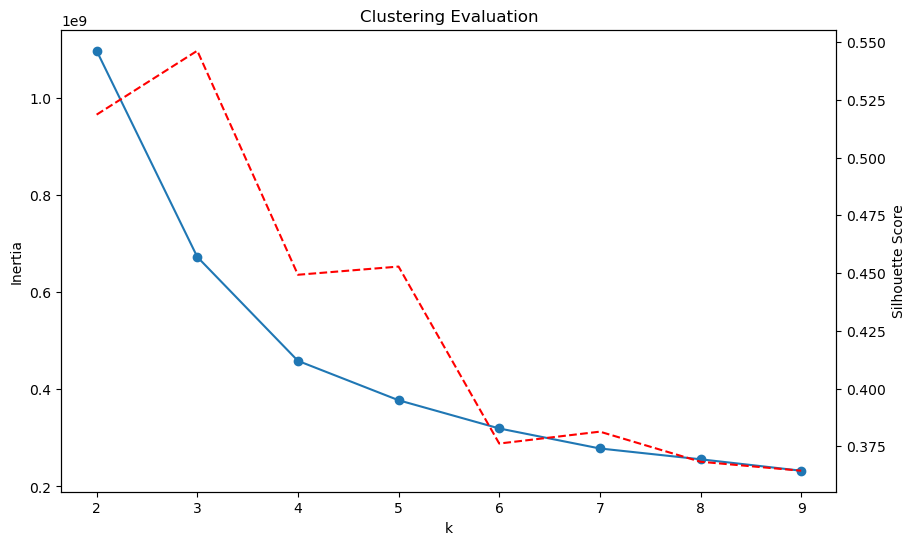

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Inertia
ax1.plot(metrics_df["k"], metrics_df["inertia"], "o-", label="Inertia")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")

# Silhouette
ax2 = ax1.twinx()
ax2.plot(metrics_df["k"], metrics_df["silhouette"], "r--", label="Silhouette")
ax2.set_ylabel("Silhouette Score")

plt.title("Clustering Evaluation")
plt.show()

## **Author**


[David Pasternak](https://www.linkedin.com/in/david-pasternak-6b84a2208/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)

[Sam Prokopchuk](https://www.linkedin.com/in/sam-prokopchuk-1908b21a0/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)

Su Wu

## **Change Log**

| Date (YYYY-MM-DD) | Version | Changed By | Change Description                 |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 2022-03-28        | 0.1     | David Pasternak      | Created Lab    |
| 2022-05-10        | 0.2     | Sam Prokopchuk      | Complete Draft of Lab    |
| 2026-05-10 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
